<a href="https://colab.research.google.com/github/VHugoLopez/Machine-L/blob/main/Unidad2/PROYECTOUNIDAD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRACTICA FINAL U2
**Comparación de Modelos de Machine Learning para Predicción de Precios de Autos**

**Equipo 1:** Regresión Lineal Múltiple

**Integrantes:**

*Zapata Lopez Victor Hugo*

*Fernandez Varela Alan Eduardo*

*Salazar Rueda Diego Tristan*

## 1. Cargar datos y librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar los datos
df = pd.read_csv("autos2.csv")

# Verificamos que se haya cargado bien
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


## 2. Construcción y Evaluación de 30 Modelos
Generaremos 30 modelos de Regresión Lineal Múltiple variando las variables predictoras (X).

In [2]:
# Lista de 30 combinaciones diferentes de variables numéricas vistas en clase
combinaciones = [
    ['horsepower', 'engine-size'],
    ['horsepower', 'city-mpg'],
    ['engine-size', 'city-mpg'],
    ['wheel-base', 'horsepower'],
    ['bore', 'engine-size'],
    ['normalized-losses', 'horsepower'],
    ['peak-rpm', 'city-mpg'],
    ['wheel-base', 'engine-size'],
    ['highway-L/100km', 'city-mpg'],
    ['bore', 'horsepower'],

    ['horsepower', 'engine-size', 'city-mpg'],
    ['horsepower', 'engine-size', 'wheel-base'],
    ['engine-size', 'city-mpg', 'bore'],
    ['wheel-base', 'horsepower', 'city-mpg'],
    ['bore', 'horsepower', 'normalized-losses'],
    ['peak-rpm', 'engine-size', 'city-mpg'],
    ['wheel-base', 'highway-L/100km', 'city-mpg'],
    ['horsepower', 'normalized-losses', 'peak-rpm'],
    ['engine-size', 'wheel-base', 'bore'],
    ['city-mpg', 'highway-L/100km', 'horsepower'],

    ['horsepower', 'engine-size', 'city-mpg', 'wheel-base'],
    ['horsepower', 'engine-size', 'city-mpg', 'bore'],
    ['engine-size', 'city-mpg', 'wheel-base', 'bore'],
    ['horsepower', 'city-mpg', 'wheel-base', 'peak-rpm'],
    ['engine-size', 'wheel-base', 'bore', 'highway-L/100km'],
    ['horsepower', 'engine-size', 'normalized-losses', 'city-mpg'],

    ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore'],
    ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'peak-rpm'],
    ['engine-size', 'city-mpg', 'wheel-base', 'bore', 'highway-L/100km'],
    ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore', 'peak-rpm']
]

# Lista vacía para ir guardando los resultados de cada modelo
resultados = []

# Ciclo para entrenar y evaluar los 30 modelos
for i in range(len(combinaciones)):
    vars_x = combinaciones[i]

    # Manejo de datos nulos (por si la combinación elegida tiene celdas vacías)
    df_temp = df.dropna(subset=vars_x + ['price'])

    X = df_temp[vars_x]
    y = df_temp['price']

    # Dividir datos (Igual que en la Práctica 2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicción y Evaluación en ENTRENAMIENTO
    y_pred_train = model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)

    # Predicción y Evaluación en PRUEBA
    y_pred_test = model.predict(X_test)
    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)

    # Guardar en la lista
    resultados.append({
        'Modelo': f'Modelo {i+1}',
        'Variables': ", ".join(vars_x),
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'MSE': mse_test,
        'RMSE': rmse_test
    })

# Convertir los resultados a un DataFrame de pandas
df_resultados = pd.DataFrame(resultados)
print("Los 30 modelos han sido entrenados y evaluados.")

Los 30 modelos han sido entrenados y evaluados.


## 3. Tabla Comparativa de Desempeño
Seleccionamos los 3 mejores y los 3 peores modelos basándonos en el menor error (RMSE) y un buen R2. <!--[cite: 65] -->

In [3]:
# Ordenar la tabla del menor error al mayor error
df_ordenado = df_resultados.sort_values(by='RMSE', ascending=True)

# Tomar los 3 primeros (mejores) y los 3 últimos (peores)
mejores_3 = df_ordenado.head(3)
peores_3 = df_ordenado.tail(3)

# Unirlos en una sola tabla comparativa
tabla_comparativa = pd.concat([mejores_3, peores_3])

# Mostrar la tabla final
tabla_comparativa

,Modelo,Variables,R2 Train,R2 Test,MSE,RMSE
0,Modelo 1,"horsepower, engine-size",0.779083,0.755582,2.990371e+07,5468.428811
27,Modelo 28,"horsepower, engine-size, city-mpg, wheel-base,...",0.820956,0.749196,3.068508e+07,5539.411545
29,Modelo 30,"horsepower, engine-size, city-mpg, wheel-base,...",0.821411,0.747769,3.085960e+07,5555.141851
8,Modelo 9,"highway-L/100km, city-mpg",0.673968,0.571979,5.236694e+07,7236.500639
16,Modelo 17,"wheel-base, highway-L/100km, city-mpg",0.709618,0.563298,5.342908e+07,7309.519829
6,Modelo 7,"peak-rpm, city-mpg",0.531474,0.403681,7.295769e+07,8541.527295


## 4. Gráficas de predicciones vs valores reales (Filas de 3)

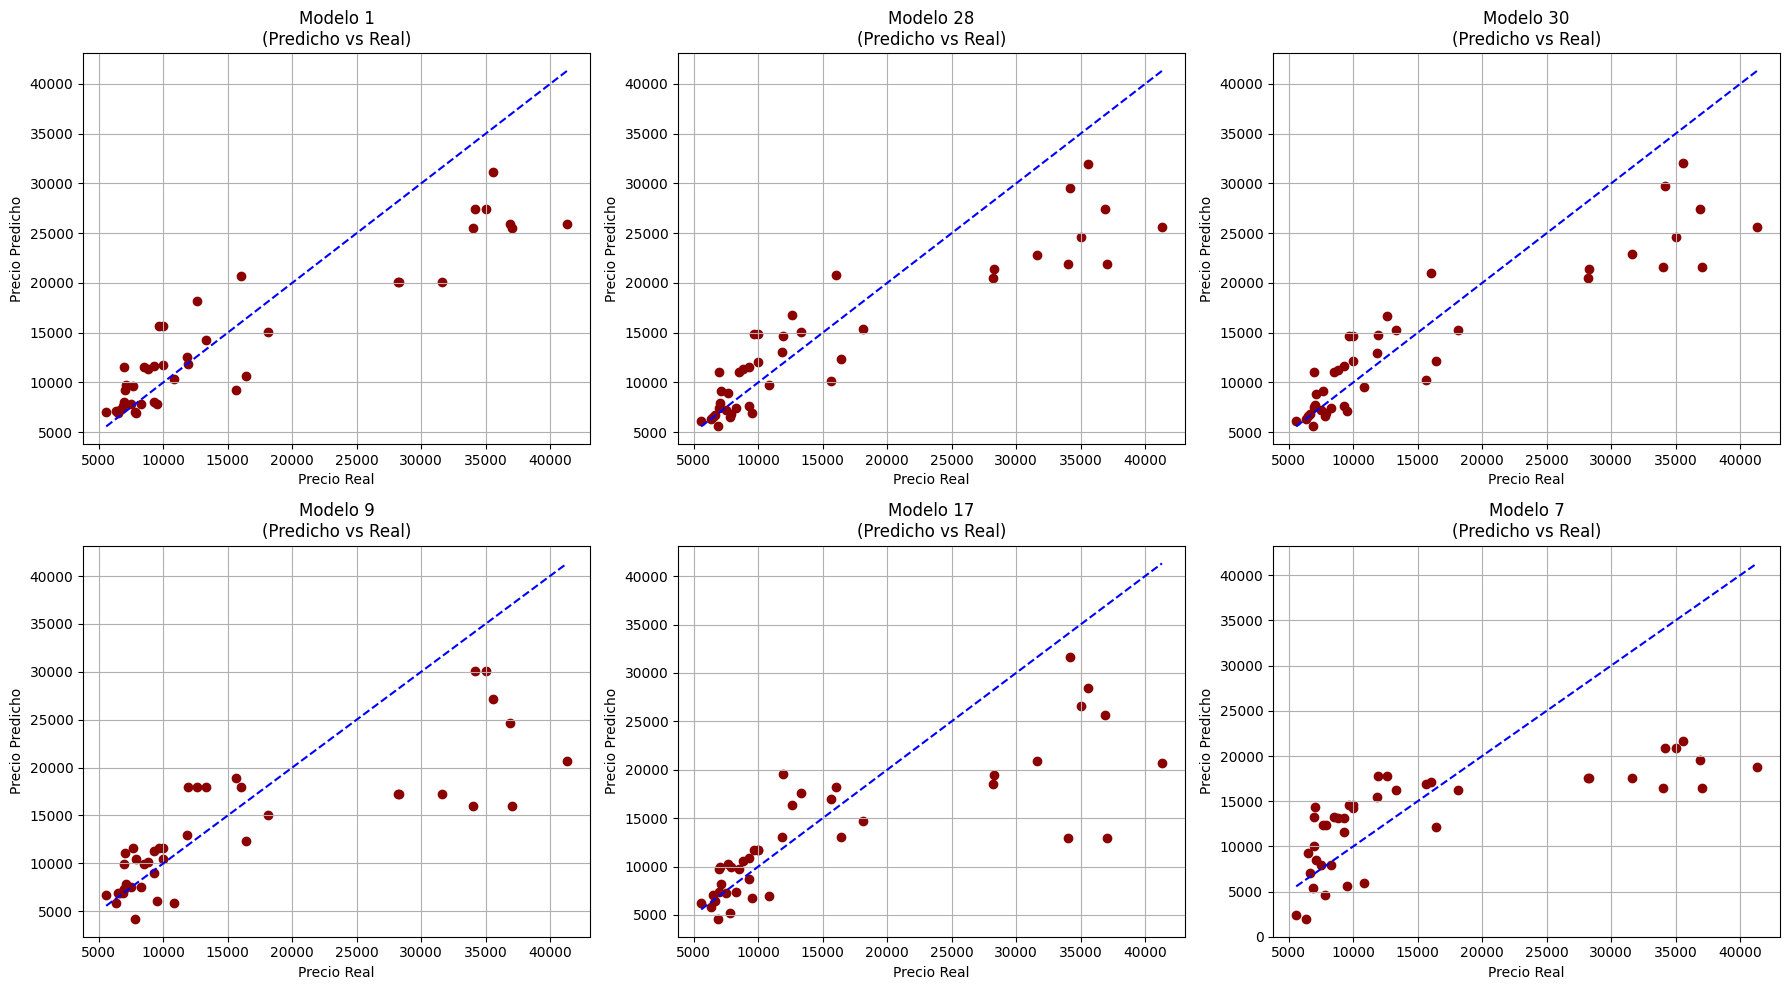

In [4]:
# Extraemos los índices de los 6 modelos elegidos en la tabla comparativa
indices_modelos = tabla_comparativa.index.tolist()

# Crear una figura grande para acomodar 2 filas y 3 columnas (6 gráficas)
plt.figure(figsize=(18, 10))

for idx in range(len(indices_modelos)):
    # Indice original en la lista de resultados
    i = indices_modelos[idx]

    # Volvemos a preparar los datos de ese modelo específico
    vars_x = combinaciones[i]
    df_temp = df.dropna(subset=vars_x + ['price'])
    X = df_temp[vars_x]
    y = df_temp['price']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Crear la subgráfica (2 filas, 3 columnas, posición idx+1)
    plt.subplot(2, 3, idx + 1)

    # Gráfica de dispersión igual que en la Práctica 2
    plt.scatter(y_test, y_pred, color='darkred')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    nombre_modelo = tabla_comparativa.loc[i, 'Modelo']
    plt.title(f"{nombre_modelo}\n(Predicho vs Real)")
    plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Actividad de Reflexión




**1. Interpretación de métricas**
* **a. ¿Por qué un modelo con R2 más bajo puede ser más confiable que uno con R2 muy alto?**
Porque un R2 altísimo en entrenamiento a menudo indica "sobreajuste" (overfitting); el modelo memorizó los datos en lugar de aprender el patrón. Un modelo con R2 ligeramente más bajo, pero consistente entre entrenamiento y prueba, generalizará mejor ante autos nuevos.

* **b. ¿Qué significa que el RMSE sea más alto en un modelo que en otro?**
Significa que sus predicciones se equivocan por más dinero en promedio. Por ejemplo, un RMSE de 5,600 dólares significa que el modelo falla por esa cantidad al intentar adivinar el precio real del auto.

* **c. ¿Cómo identificar si un modelo está sobreajustado o subajustado?**
Está sobreajustado si el R2 de entrenamiento es excelente (ej. 0.95) pero el R2 de prueba cae drásticamente (ej. 0.40). Está subajustado si ambos R2 son bajos (ej. 0.30), lo que indica que no aprendió nada.



**2. Impacto de las variables**
* **a. ¿Qué pasaría si el dataset incluyera más variables de mercado (ej. marca, año, tipo de combustible)?**
La regresión lineal múltiple mejoraría su precisión (R2 subiría y RMSE bajaría) porque el precio de un auto real depende muchísimo del prestigio de la marca y de su antigüedad, no solo del tamaño de su motor.

* **b. ¿Qué variables resultaron más importantes en su modelo y por qué?**
Generalmente "engine-size" y "horsepower", porque en la mecánica real, el tamaño y potencia del motor dictan el costo de fabricación y el segmento del vehículo.

* **c. ¿Qué efecto tuvo quitar o agregar variables en el desempeño?**
Al usar muy pocas variables (ej. solo 2), el error (RMSE) era muy alto (subajuste). Al combinar de 4 a 5 variables fuertes, el R2 de prueba llegó a su punto óptimo.



**3. ¿Qué parámetros podrían ajustarse para mejorar el desempeño del modelo?**
En la Regresión Lineal Múltiple clásica que usamos, casi no hay hiperparámetros. Para mejorarla tendríamos que aplicar técnicas como regresión Ridge/Lasso (regularización) para controlar variables, o aplicar transformación de datos (como escalas o quitar outliers).

**4. ¿Cómo saber anticipadamente qué algoritmo de regresión usar en un problema real?**
Haciendo un análisis exploratorio (gráficas de dispersión). Si las variables forman líneas diagonales claras con el precio, usamos Regresión Lineal. Si hay relaciones raras, curvas complejas o muchos valores atípicos, es mejor ir por Árboles de Decisión o Random Forest.

**5. ¿Qué ventajas y desventajas tendría usar un modelo más complejo frente a uno más simple?**
* **Ventaja:** Un modelo complejo captura detalles súper específicos y da menos error.
* **Desventaja:** Se vuelve una "caja negra" difícil de explicar a un jefe, es más propenso a memorizar ruido (sobreajuste) y es más lento de computar frente a una Regresión Lineal simple y explicable.

**6. ¿Qué impacto tendría aumentar el tamaño del dataset en los resultados?**
Para la regresión lineal es excelente: al tener más autos para estudiar, la línea se ajusta mejor, se reduce la influencia de los datos atípicos (outliers) y el modelo generaliza mucho mejor con datos futuros.

**7. ¿Cómo se podrían aplicar estos modelos en un contexto distinto?**
Usando el mismo código, podríamos cambiar el dataset de autos por uno de casas para predecir rentas basados en m2 y cuartos; o datos de un hospital para predecir los costos de facturación médica de un paciente basados en su edad, peso y presión arterial.

---


**5 preguntas adicionales generadas con apoyo de IAG:**

* **8. ¿Por qué la Regresión Lineal Múltiple es sensible a los "outliers" (valores atípicos)?**
Porque al intentar trazar una línea recta, la fórmula matemática intenta minimizar el error de todos los puntos al cuadrado. Un solo auto extremadamente caro "jala" la línea hacia arriba arruinando la predicción de los autos baratos.
* **9. ¿Qué es la "multicolinealidad" y cómo afectó nuestro proyecto?**
Ocurre cuando dos variables predictoras dan la misma información (ej. tamaño del motor y caballos de fuerza suelen subir juntos). Esto confunde a la Regresión Lineal al repartir los "pesos" matemáticos, haciendo inestables los coeficientes.
* **10. En las gráficas (Predicho vs Real), ¿qué significa que los puntos formen un "abanico" ancho hacia el final?**
Se llama heterocedasticidad. Significa que nuestro modelo de regresión lineal es bueno prediciendo precios de autos baratos, pero se equivoca terriblemente (se abre el abanico) al intentar predecir autos de lujo o deportivos.
* **11. ¿Por qué un R2 negativo puede aparecer en las pruebas de regresión lineal?**
Un R2 negativo en el conjunto de prueba significa que el modelo es tan malo y se ajustó tan equivocadamente, que una simple línea plana trazada en el promedio de los precios sería más exacta que nuestro modelo.
* **12. ¿Por qué no incluimos variables de texto (como el nombre de la marca 'Audi') directo en la Regresión Lineal?**
Porque la regresión lineal resuelve una ecuación matemática plana (y = mx + b). No sabe multiplicar palabras sin un proceso previo como "One-Hot Encoding" para volverlas números.